## Pregenerate maps

This notebook creates the larger maps that the app will want to draw from ahead of time to reduce runtime calls from generating things in real time.

### Import necessary functions

In [14]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [15]:
import os

### Little hack to reproducibly set working dir as the project directory (one level up) in notebooks
if "original_dir" not in vars():
    original_dir = os.path.abspath("")

os.chdir(original_dir)
os.chdir("..")  ### Adjust as needed to get to root
print(f"Project root (ensure this is correct): {os.getcwd()}")

import geopandas as gpd
import pandas as pd
import folium
from src.io_utils import io_utils
import src.preprocessing.pregenerated_maps as funcs
import src.cleaning_functions.general_cleaning_functions as general_cleaning_functions
from concurrent.futures import ThreadPoolExecutor, as_completed
import warnings
from sqlalchemy import create_engine

warnings.filterwarnings("ignore")  # annoying kmeans warning for windows
pd.set_option("display.max_columns", 999)
from app.src.config import BASE_PATH, DB_SERVER, DB_PORT, DB_NAME, DB_USERNAME, DB_PASSWORD
crs_thailand = io_utils.load_param("crs_thailand") 

Project root (ensure this is correct): c:\Users\Francesca Andretta\vegx_thailand_front_end


### Load data

In [16]:
if "engine" not in globals():
    general_cleaning_functions.log_detail("Initialize database engine.")
    connection_string = (
                f"mssql+pyodbc://{DB_USERNAME}:{DB_PASSWORD}@{DB_SERVER},{DB_PORT}/"
                f"{DB_NAME}?driver=ODBC+Driver+17+for+SQL+Server&timeout=120&Encrypt=no"
            )
    engine = create_engine(connection_string, pool_size=5, max_overflow=10)
else:
    general_cleaning_functions.log_detail("Reusing the existing database engine.")

	Reusing the existing database engine.


In [17]:
devices, _= io_utils.read_from_db("protective_devices", "corridor_model", engine)
devices.crs = crs_thailand
veg_clusters, _= io_utils.read_from_db("veg_clusters", "front_end_visualization", engine)
veg_clusters.crs = crs_thailand
corridors, _= io_utils.read_from_db("veg_features", "front_end_visualization", engine)
corridors.crs = crs_thailand
aoj_df, _= io_utils.read_from_db("areas_of_jurisdiction", "corridor_model", engine)
aoj_df.crs = crs_thailand

### Load parameters

In [18]:
pregenerate_maps_parameters = io_utils.load_param("pregenerate_maps_parameters")
local_path = io_utils.load_param("local_path")

### Process Data

In [19]:
veg_clusters = funcs.rename_columns(
    veg_clusters, pregenerate_maps_parameters["veg_clusters_rename"]
)

In [20]:
veg_clusters = funcs.rename_columns(
    veg_clusters, pregenerate_maps_parameters["veg_clusters_rename"]
)
corridors = funcs.rename_columns(
    corridors, pregenerate_maps_parameters["veg_features_rename"]
)
veg_clusters = funcs.round_columns(
    veg_clusters, pregenerate_maps_parameters["veg_clusters_round"], decimals=2
)
corridors = funcs.round_columns(
    corridors, pregenerate_maps_parameters["veg_features_round"], decimals=2
)
corridors = funcs.filter_columns(
    corridors, pregenerate_maps_parameters["corridors_columns"]
)
feeder_level_map_views = funcs.map_views(
    veg_clusters, pregenerate_maps_parameters["feeder_level_map_views_exclude"]
)
corridor_level_map_views = funcs.map_views(
    corridors, pregenerate_maps_parameters["corridor_level_map_views_exclude"]
)
aoj = funcs.clean_column_values(aoj_df, "NAME", r"\.", "")

### Create Maps

In [21]:
def run_in_parallel(func, features):
    with ThreadPoolExecutor(max_workers=1) as executor:
        futures = [executor.submit(func, feature) for feature in features]
        for i, future in enumerate(as_completed(futures), 1):
            try:
                future.result()
                print(f"Task {i}/{len(futures)} completed successfully.")
            except Exception as e:
                print(f"Task {i}/{len(futures)} failed with error: {e}")


def veg_region(feature):
    path = os.path.join(
        local_path,
        "regional_maps",
        "Vegetation Management",
        aoj + "_" + feature + ".html",
    )
    os.makedirs(os.path.dirname(path), exist_ok=True)
    print(f"Generating map for: {path}")

    m = funcs.generate_regional_map(
        veg_clusters.loc[veg_clusters["Area of Jurisdiction"] == aoj], feature
    )
    m.save(path, encoding="utf-8")
    funcs.add_zoom_in_function(path, cluster_field="Feeder ID")


for aoj in veg_clusters["Area of Jurisdiction"].drop_duplicates():
    run_in_parallel(veg_region, feeder_level_map_views)

Generating map for: app/assets\regional_maps\Vegetation Management\กฟสพุนพิน_Avg. Prob. Outage (%).html
Task 1/6 completed successfully.
Generating map for: app/assets\regional_maps\Vegetation Management\กฟสพุนพิน_Cost to Trim (BHT) [META + Sentinel-2].html
Task 2/6 completed successfully.
Generating map for: app/assets\regional_maps\Vegetation Management\กฟสพุนพิน_Cost to Trim (BHT) [MJM].html
Generating map for: app/assets\regional_maps\Vegetation Management\กฟสพุนพิน_Customers Affected (Original).html
Task 3/6 completed successfully.
Task 4/6 completed successfully.
Generating map for: app/assets\regional_maps\Vegetation Management\กฟสพุนพิน_Customers Affected (Adjusted).html
Generating map for: app/assets\regional_maps\Vegetation Management\กฟสพุนพิน_Risk (Customer Interruptions).htmlTask 5/6 completed successfully.

Task 6/6 completed successfully.
Generating map for: app/assets\regional_maps\Vegetation Management\กฟสคีรีรัฐนิคม_Avg. Prob. Outage (%).html
Task 1/6 completed succes

### seperate device dataframe into assets and sources

In [22]:
# Create device dataframe for sources
devices_source = devices[devices["device_type"] == "Source"].reset_index(drop=True)

# Create a buffer around the point (e.g., with a radius of 1 unit)
devices_source["geometry"] = devices_source["geometry"].buffer(30)

# Get the envelope (bounding box) of the buffer
devices_source["geometry"] = devices_source["geometry"].envelope

# Create device dataframe for devices

devices_assets = devices[devices["device_type"] != "Source"].reset_index(drop=True)
devices_assets["device_type"] = devices_assets["device_type"].replace(
    {"Dynamic Protective Device": "recloser"}
)
devices_assets.head()

,connector_id,FEEDERID,device_type,geometry,FACILITYID,full_nearest_upstream_device
0,4280RC000000001,NTA06,recloser,POINT (597084.147 912222.425),NTA06WR-104,NTA06WR-104-4280RC000000001
1,4280RC000000002,NTA06,recloser,POINT (597974.882 911509.661),NTA06WR-103,NTA06WR-103-4280RC000000002
2,4280RC000000003,NTA03,recloser,POINT (594910.308 903532.094),NTA03WR-104,NTA03WR-104-4280RC000000003
3,4280RC000000004,NTA06,recloser,POINT (599493.967 914687.054),NTA06WR-102,NTA06WR-102-4280RC000000004
4,4280RC000000005,NTA03,recloser,POINT (599738.582 915150.667),NTA03WR-102,NTA03WR-102-4280RC000000005


## Generate Sub Regional Maps

These are the maps of each region's assets. Some assets may appear in more than one region and that's fine

In [23]:
def veg_subregion(cluster):
    path = os.path.join(
        local_path,
        "subregional_maps",
        "Vegetation Management",
        f"{feature}_{cluster}.html",
    )
    os.makedirs(os.path.dirname(path), exist_ok=True)
    m = funcs.generate_subregional_map(
        corridors.loc[corridors["Feeder ID"] == cluster],
        feature,
        ### These vmin and vmax entires determine the logic of the color scheme upper and lower bounds
        vmin=(
            corridors[feature].quantile(0.2)
            if type(corridors[feature].iloc[0]) != str
            else None
        ),
        vmax=(
            corridors[feature].quantile(0.9)
            if type(corridors[feature].iloc[0]) != str
            else None
        ),
        shape_type="lines",
    )

    m = devices_source.loc[devices_source["FEEDERID"] == cluster].explore(
        m=m,
        column="device_type",
        color="black",
        name="sources",
        style_kwds={"weight": 10},
    )

    # assets map
    custom_colors = [
        "#8B4513",  # SaddleBrown
        "#FF8C00",  # DarkOrange
        "#800080",  # Purple
        "#8B008B",  # DarkMagenta
        "#483D8B",  # DarkSlateBlue
        "#708090",  # SlateGray
        "#2F4F4F",  # DarkSlateGray
        "#DA70D6",  # Orchid
    ]
    devices_assets_cluster = devices_assets.loc[devices_assets["FEEDERID"] == cluster]
    if not devices_assets_cluster.empty:
        m = devices_assets_cluster.explore(
            m=m,
            column="device_type",
            cmap=custom_colors,
            name="devices",
            style_kwds={"weight": 10},
        )
    else:
        print(f"No data for devices_assets for cluster {cluster}")

    ### For some reason this MUST be called AFTER adding extra shape layers otherwise the extra layers don't show?
    folium.LayerControl().add_to(m)

    m.save(path)
    funcs.add_asset_selection_function(path, "Nearest Upstream Device")


for feature in corridor_level_map_views[::-1]:
    print(f"Generating maps for {feature}")
    run_in_parallel(veg_subregion, corridors["Feeder ID"].drop_duplicates())

Generating maps for Chosen Scenario
Task 1/31 completed successfully.
Task 2/31 completed successfully.
Task 3/31 completed successfully.
Task 4/31 completed successfully.
Task 5/31 completed successfully.
Task 6/31 completed successfully.
Task 7/31 completed successfully.
Task 8/31 completed successfully.
Task 9/31 completed successfully.
Task 10/31 completed successfully.
Task 11/31 completed successfully.
Task 12/31 completed successfully.
Task 13/31 completed successfully.
Task 14/31 completed successfully.
Task 15/31 completed successfully.
Task 16/31 completed successfully.
Task 17/31 completed successfully.
Task 18/31 completed successfully.
Task 19/31 completed successfully.
Task 20/31 completed successfully.
Task 21/31 completed successfully.
Task 22/31 completed successfully.
Task 23/31 completed successfully.
Task 24/31 completed successfully.
Task 25/31 completed successfully.
Task 26/31 completed successfully.
Task 27/31 completed successfully.
Task 28/31 completed success

#### Areas of Jurisdiction

In [24]:
m = aoj_df[["NAME", "geometry"]].explore(
    color="#460D5C", tiles=folium.TileLayer("cartodbpositron", min_zoom=8)
)

path = os.path.join(local_path, f"areas_of_jurisdiction_map.html")

m.save(path)
funcs.add_aoj_selection_function(path, aoj_name_column="NAME")

### Save

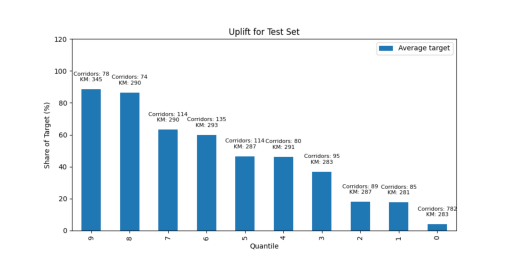

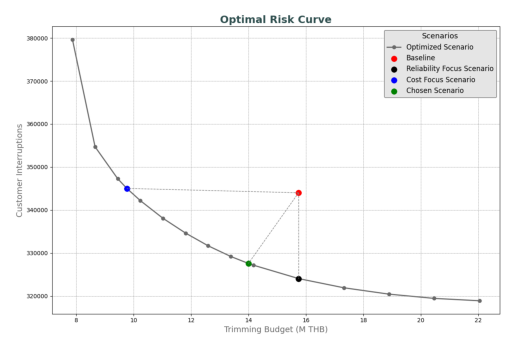

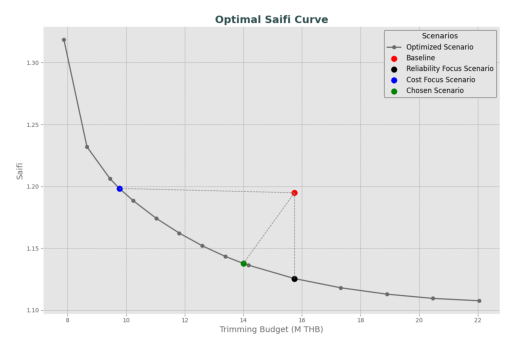

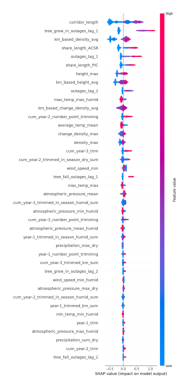

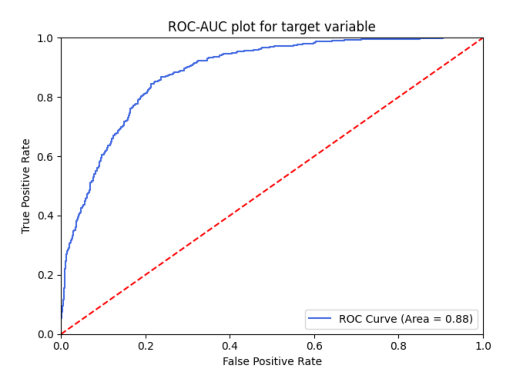

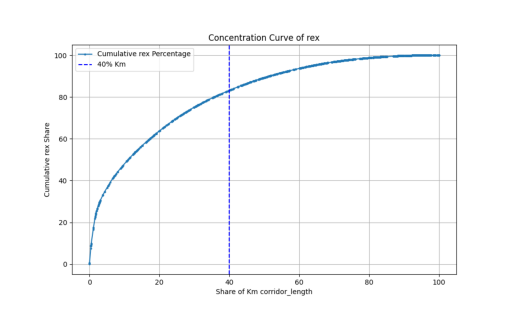

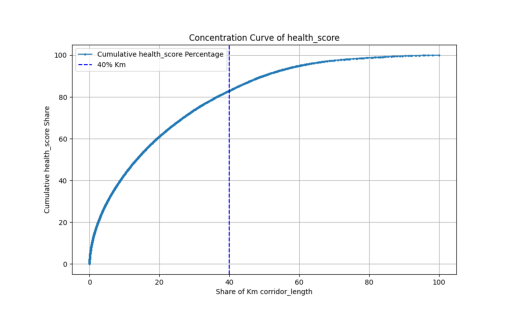

In [25]:
io_utils.load_and_save_images("model_outputs_decile_km_image", "risk_modeling", local_path, engine)
io_utils.load_and_save_images("opti_curve_risk_image", "risk_modeling", local_path,  engine)
io_utils.load_and_save_images("opti_curve_saifi_image", "risk_modeling", local_path, engine)
io_utils.load_and_save_images("model_outputs_shaps_image", "risk_modeling", local_path, engine)
io_utils.load_and_save_images("roc_image", "risk_modeling", local_path, engine)
io_utils.load_and_save_images("risk_concentration_image", "risk_modeling", local_path, engine)
io_utils.load_and_save_images("model_outputs_health_concentration_image", "risk_modeling", local_path, engine)